In [2]:
import pandas as pd

In [4]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Amazon_Reviews.csv.zip", engine='python', on_bad_lines='warn')

In [5]:
df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [10]:
def get_sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df['Rating'].str.extract(r'(\d+)', expand=False).fillna(0).astype(int).apply(get_sentiment_label)

In [12]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

df["Cleaned_Review"] = df["Review Text"].apply(clean_text)

In [13]:
from textblob import TextBlob

def analyze_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Predicted_Sentiment"] = df["Cleaned_Review"].apply(analyze_sentiment)

In [14]:
print(pd.crosstab(df["Sentiment"], df["Predicted_Sentiment"]))

Predicted_Sentiment  Negative  Neutral  Positive
Sentiment                                       
Negative                 7878     1358      5273
Neutral                   219      114       552
Positive                  336      721      4763


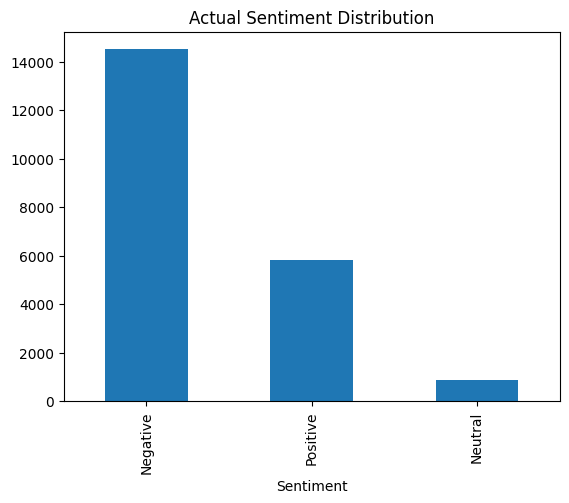

In [15]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(kind='bar')
plt.title("Actual Sentiment Distribution")
plt.show()